In [12]:
# imports
import numpy as np
import pandas as pd
import sys

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
plt.style.use('scifigs.mplstyle')
SAVE_FIG = True

sys.path.append('helpers/')
from dual_pfc_funcs import load_dict, getParams, get_top_angle
import helpers.pcca_fa.pcca_fa_mdl as pf
color_map = getParams()['color_map']

In [13]:
fname = 'preprocessed_data/simdataset_varyTheta.pkl'
# fname = 'preprocessed_data/simdataset_varyTheta_5D.pkl'
dat = load_dict(fname)
n_boots = dat['n_boots']
thetas = dat['thetas']
theta_list = []
for theta in thetas:
    for j in range(n_boots):
        theta_list.append(theta)
# GT SV:
sv_across = dat['sv'][0]
sv_within = dat['sv'][1]
ind_var = 100 - (sv_across + sv_within)

In [14]:
df = pd.DataFrame(columns=['Theta','GT-ThetaX','GT-ThetaY',
                           'GT-WxSv','GT-WySv','GT-LxSv','GT-LySv','GT-XIndV','GT-YIndV',
                           'Est-WxSv','Est-WySv','Est-LxSv','Est-LySv','Est-XIndV','Est-YIndV',
                           'Error-WxSv','Error-WySv','Error-LxSv','Error-LySv','Error-XIndV','Error-YIndV',
                           'Est-ThetaX','Est-ThetaY','Error-ThetaX','Error-ThetaY'])

for (gt,est,theta) in zip(dat['sim_params'],dat['est_params'],theta_list):
    mdl = pf.pcca_fa()
    mdl.set_params(gt)
    psv_gt = mdl.compute_psv().copy()
    gt_thetax,gt_thetay = get_top_angle(gt)

    gt_ind_var_x = np.mean(psv_gt['ind_priv_x'])
    gt_ind_var_y = np.mean(psv_gt['ind_priv_y'])

    mdl = pf.pcca_fa()
    mdl.set_params(est)
    psv_est = mdl.compute_psv().copy()
    est_thetax,est_thetay = get_top_angle(est)

    est_ind_var_x = np.mean(psv_est['ind_priv_x'])
    est_ind_var_y = np.mean(psv_est['ind_priv_y'])

    df2 = {'Theta':theta,'GT-ThetaX':gt_thetax,'GT-ThetaY':gt_thetay,'Est-ThetaX':est_thetax,'Est-ThetaY':est_thetay,'Error-ThetaX':est_thetax-theta,'Error-ThetaY':est_thetay-theta,
           'GT-WxSv':psv_gt['psv_x'],'GT-WySv':psv_gt['psv_y'],'GT-LxSv':psv_gt['psv_priv_x'],'GT-LySv':psv_gt['psv_priv_y'],'GT-XIndV':gt_ind_var_x,'GT-YIndV':gt_ind_var_y,
           'Est-WxSv':psv_est['psv_x'],'Est-WySv':psv_est['psv_y'],'Est-LxSv':psv_est['psv_priv_x'],'Est-LySv':psv_est['psv_priv_y'],'Est-XIndV':est_ind_var_x,'Est-YIndV':est_ind_var_y,
           'Error-WxSv':psv_est['psv_x']-psv_gt['psv_x'],'Error-WySv':psv_est['psv_y']-psv_gt['psv_y'],'Error-LxSv':psv_est['psv_priv_x']-psv_gt['psv_priv_x'],'Error-LySv':psv_est['psv_priv_y']-psv_gt['psv_priv_y'],'Error-XIndV':est_ind_var_x-gt_ind_var_x,'Error-YIndV':est_ind_var_y-gt_ind_var_y}
    df.loc[len(df)] = df2
# df

,Theta,GT-ThetaX,GT-ThetaY,GT-WxSv,GT-WySv,GT-LxSv,GT-LySv,GT-XIndV,GT-YIndV,Est-WxSv,...,Error-WxSv,Error-WySv,Error-LxSv,Error-LySv,Error-XIndV,Error-YIndV,Est-ThetaX,Est-ThetaY,Error-ThetaX,Error-ThetaY
0,0,0.0,0.0,15.283412,14.706737,9.716588,10.293263,75.0,75.0,13.413307,...,-1.870105,2.528275,1.954445,-1.411222,-0.084339,-1.117053,86.177390,68.459321,86.177390,68.459321
1,0,0.0,0.0,15.066174,15.438870,9.933826,9.561130,75.0,75.0,18.507914,...,3.441740,-0.549721,-1.695734,1.328177,-1.746006,-0.778457,70.344579,27.111404,70.344579,27.111404
2,0,0.0,0.0,15.663026,15.818086,9.336974,9.181914,75.0,75.0,14.192715,...,-1.470312,3.922108,2.131461,-2.101076,-0.661149,-1.821031,80.662104,85.919326,80.662104,85.919326
3,0,0.0,0.0,15.108985,14.960495,9.891015,10.039505,75.0,75.0,19.911924,...,4.802939,-0.951530,-2.313446,2.153621,-2.489493,-1.202092,82.815781,28.694133,82.815781,28.694133
4,0,0.0,0.0,15.108890,15.469193,9.891110,9.530807,75.0,75.0,19.381231,...,4.272341,-2.489147,-2.451628,3.169235,-1.820713,-0.680088,80.537586,73.348284,80.537586,73.348284
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1295,90,90.0,90.0,15.662631,14.130127,9.337369,10.869873,75.0,75.0,16.120745,...,0.458115,0.370303,0.227938,0.891723,-0.686053,-1.262026,84.819689,87.248462,-5.180311,-2.751538
1296,90,90.0,90.0,15.700930,14.356767,9.299070,10.643233,75.0,75.0,15.776563,...,0.075633,0.455292,0.326021,-0.149832,-0.401654,-0.305460,85.707343,87.829133,-4.292657,-2.170867
1297,90,90.0,90.0,15.375863,15.067106,9.624137,9.932894,75.0,75.0,15.586557,...,0.210694,1.002142,0.776524,-0.602848,-0.987218,-0.399294,84.319890,87.095922,-5.680110,-2.904078
1298,90,90.0,90.0,15.039108,15.880337,9.960892,9.119663,75.0,75.0,15.695061,...,0.655953,-0.684250,-0.656876,0.263781,0.000923,0.420470,89.387109,89.060633,-0.612891,-0.939367


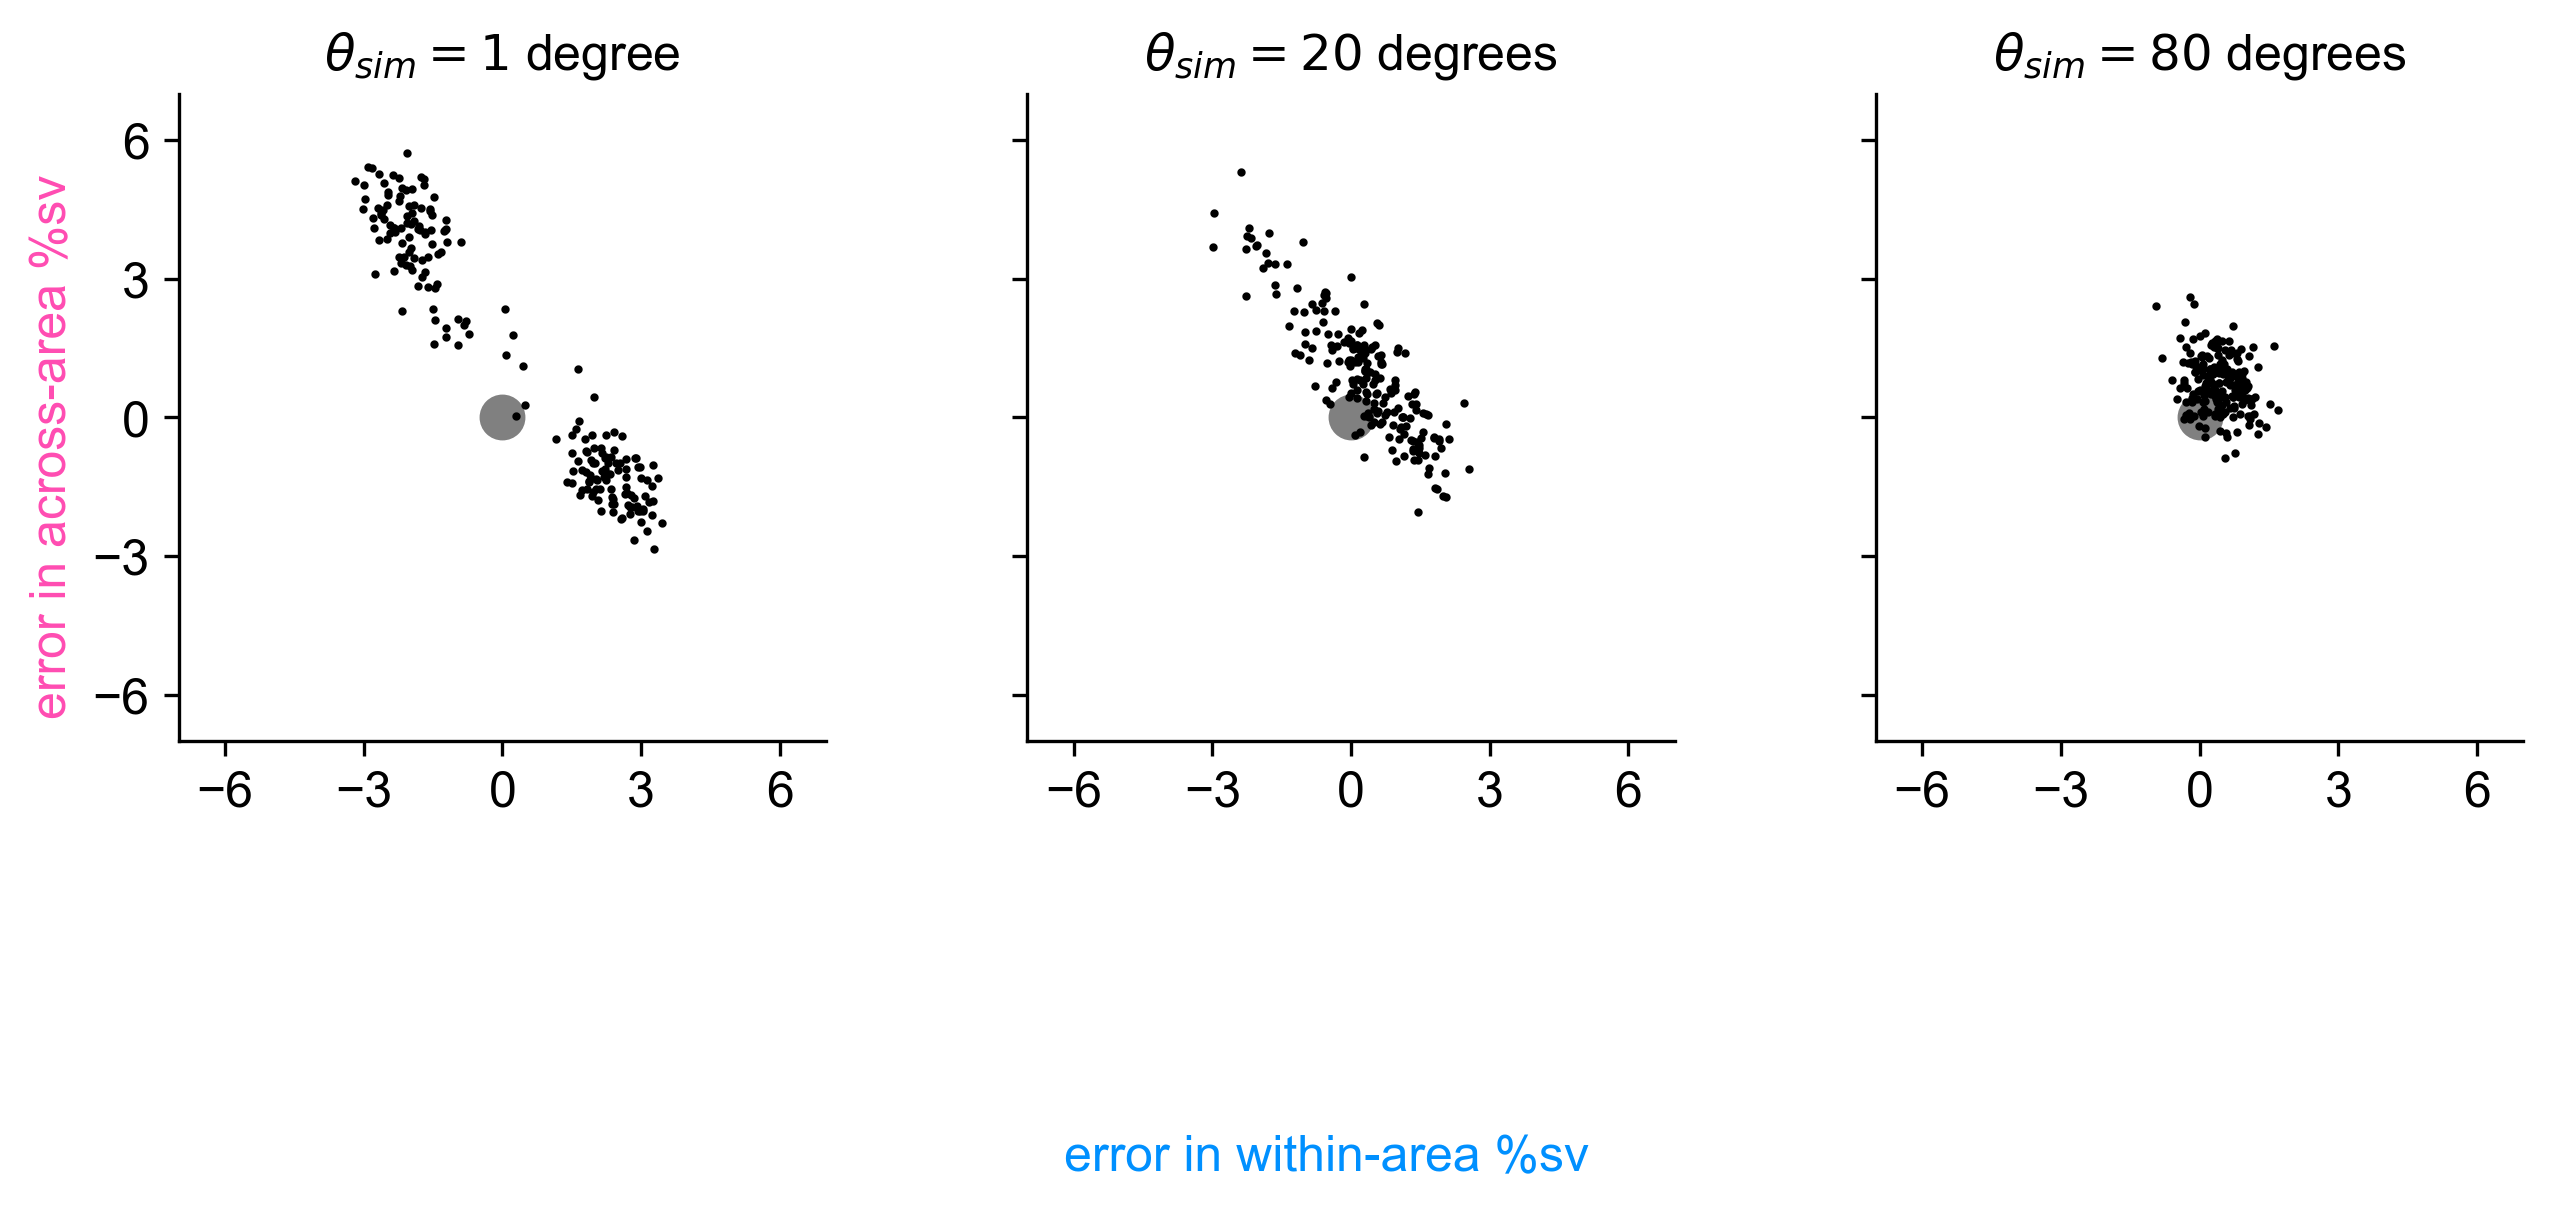

In [15]:
ms = 1 # marker size
lims = 7
ticks = np.arange(-lims,lims,3)+1
fig,ax = plt.subplots(1,3,sharex=True,sharey=True,figsize=(9,5))
fig.tight_layout(pad=2.5)

fig.supxlabel('error in within-area %sv',color=color_map['within'])
fig.supylabel('error in across-area %sv',color=color_map['across'])

ax[0].scatter(0,0,s=100,color='gray', marker='o')
ax[1].scatter(0,0,s=100,color='gray', marker='o')
ax[2].scatter(0,0,s=100,color='gray', marker='o')

ax[0].plot(df[df['Theta']==1]['Error-LxSv'], df[df['Theta']==1]['Error-WxSv'], color='black', ms=ms, ls='',marker='o')
ax[1].plot(df[df['Theta']==20]['Error-LxSv'], df[df['Theta']==20]['Error-WxSv'], color='black', ms=ms, ls='',marker='o')
ax[2].plot(df[df['Theta']==80]['Error-LxSv'], df[df['Theta']==80]['Error-WxSv'], color='black', ms=ms, ls='',marker='o')

ax[0].plot(df[df['Theta']==1]['Error-LySv'], df[df['Theta']==1]['Error-WySv'], color='black', ms=ms, ls='',marker='o')
ax[1].plot(df[df['Theta']==20]['Error-LySv'], df[df['Theta']==20]['Error-WySv'], color='black', ms=ms, ls='',marker='o')
ax[2].plot(df[df['Theta']==80]['Error-LySv'], df[df['Theta']==80]['Error-WySv'], color='black', ms=ms, ls='',marker='o')

# n = 173 # mark example sim for legend
# ax[0].plot(df.iloc[n]['Error-LxSv'], df.iloc[n]['Error-WxSv'], color='green', ms=ms, ls='',marker='o')
# ax[0].plot(df.iloc[n]['Error-LySv'], df.iloc[n]['Error-WySv'], color='green', ms=ms, ls='',marker='o')

ax[0].set_title(r'$\theta_{sim} = 1$ degree')
ax[1].set_title(r'$\theta_{sim} = 20$ degrees')
ax[2].set_title(r'$\theta_{sim} = 80$ degrees')

ax[0].set_xlim([-lims,lims]),ax[0].set_ylim([-lims,lims])
ax[0].set_xticks(ticks),ax[0].set_yticks(ticks)

ax[0].set_aspect('equal')
ax[1].set_aspect('equal')
ax[2].set_aspect('equal')

if SAVE_FIG:
    pdf = PdfPages('figs/sv_error_ex_theta.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

/var/folders/n6/25pbyfj56mj_j3jqsv8rcw480000gn/T/ipykernel_12824/4262892799.py:39: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


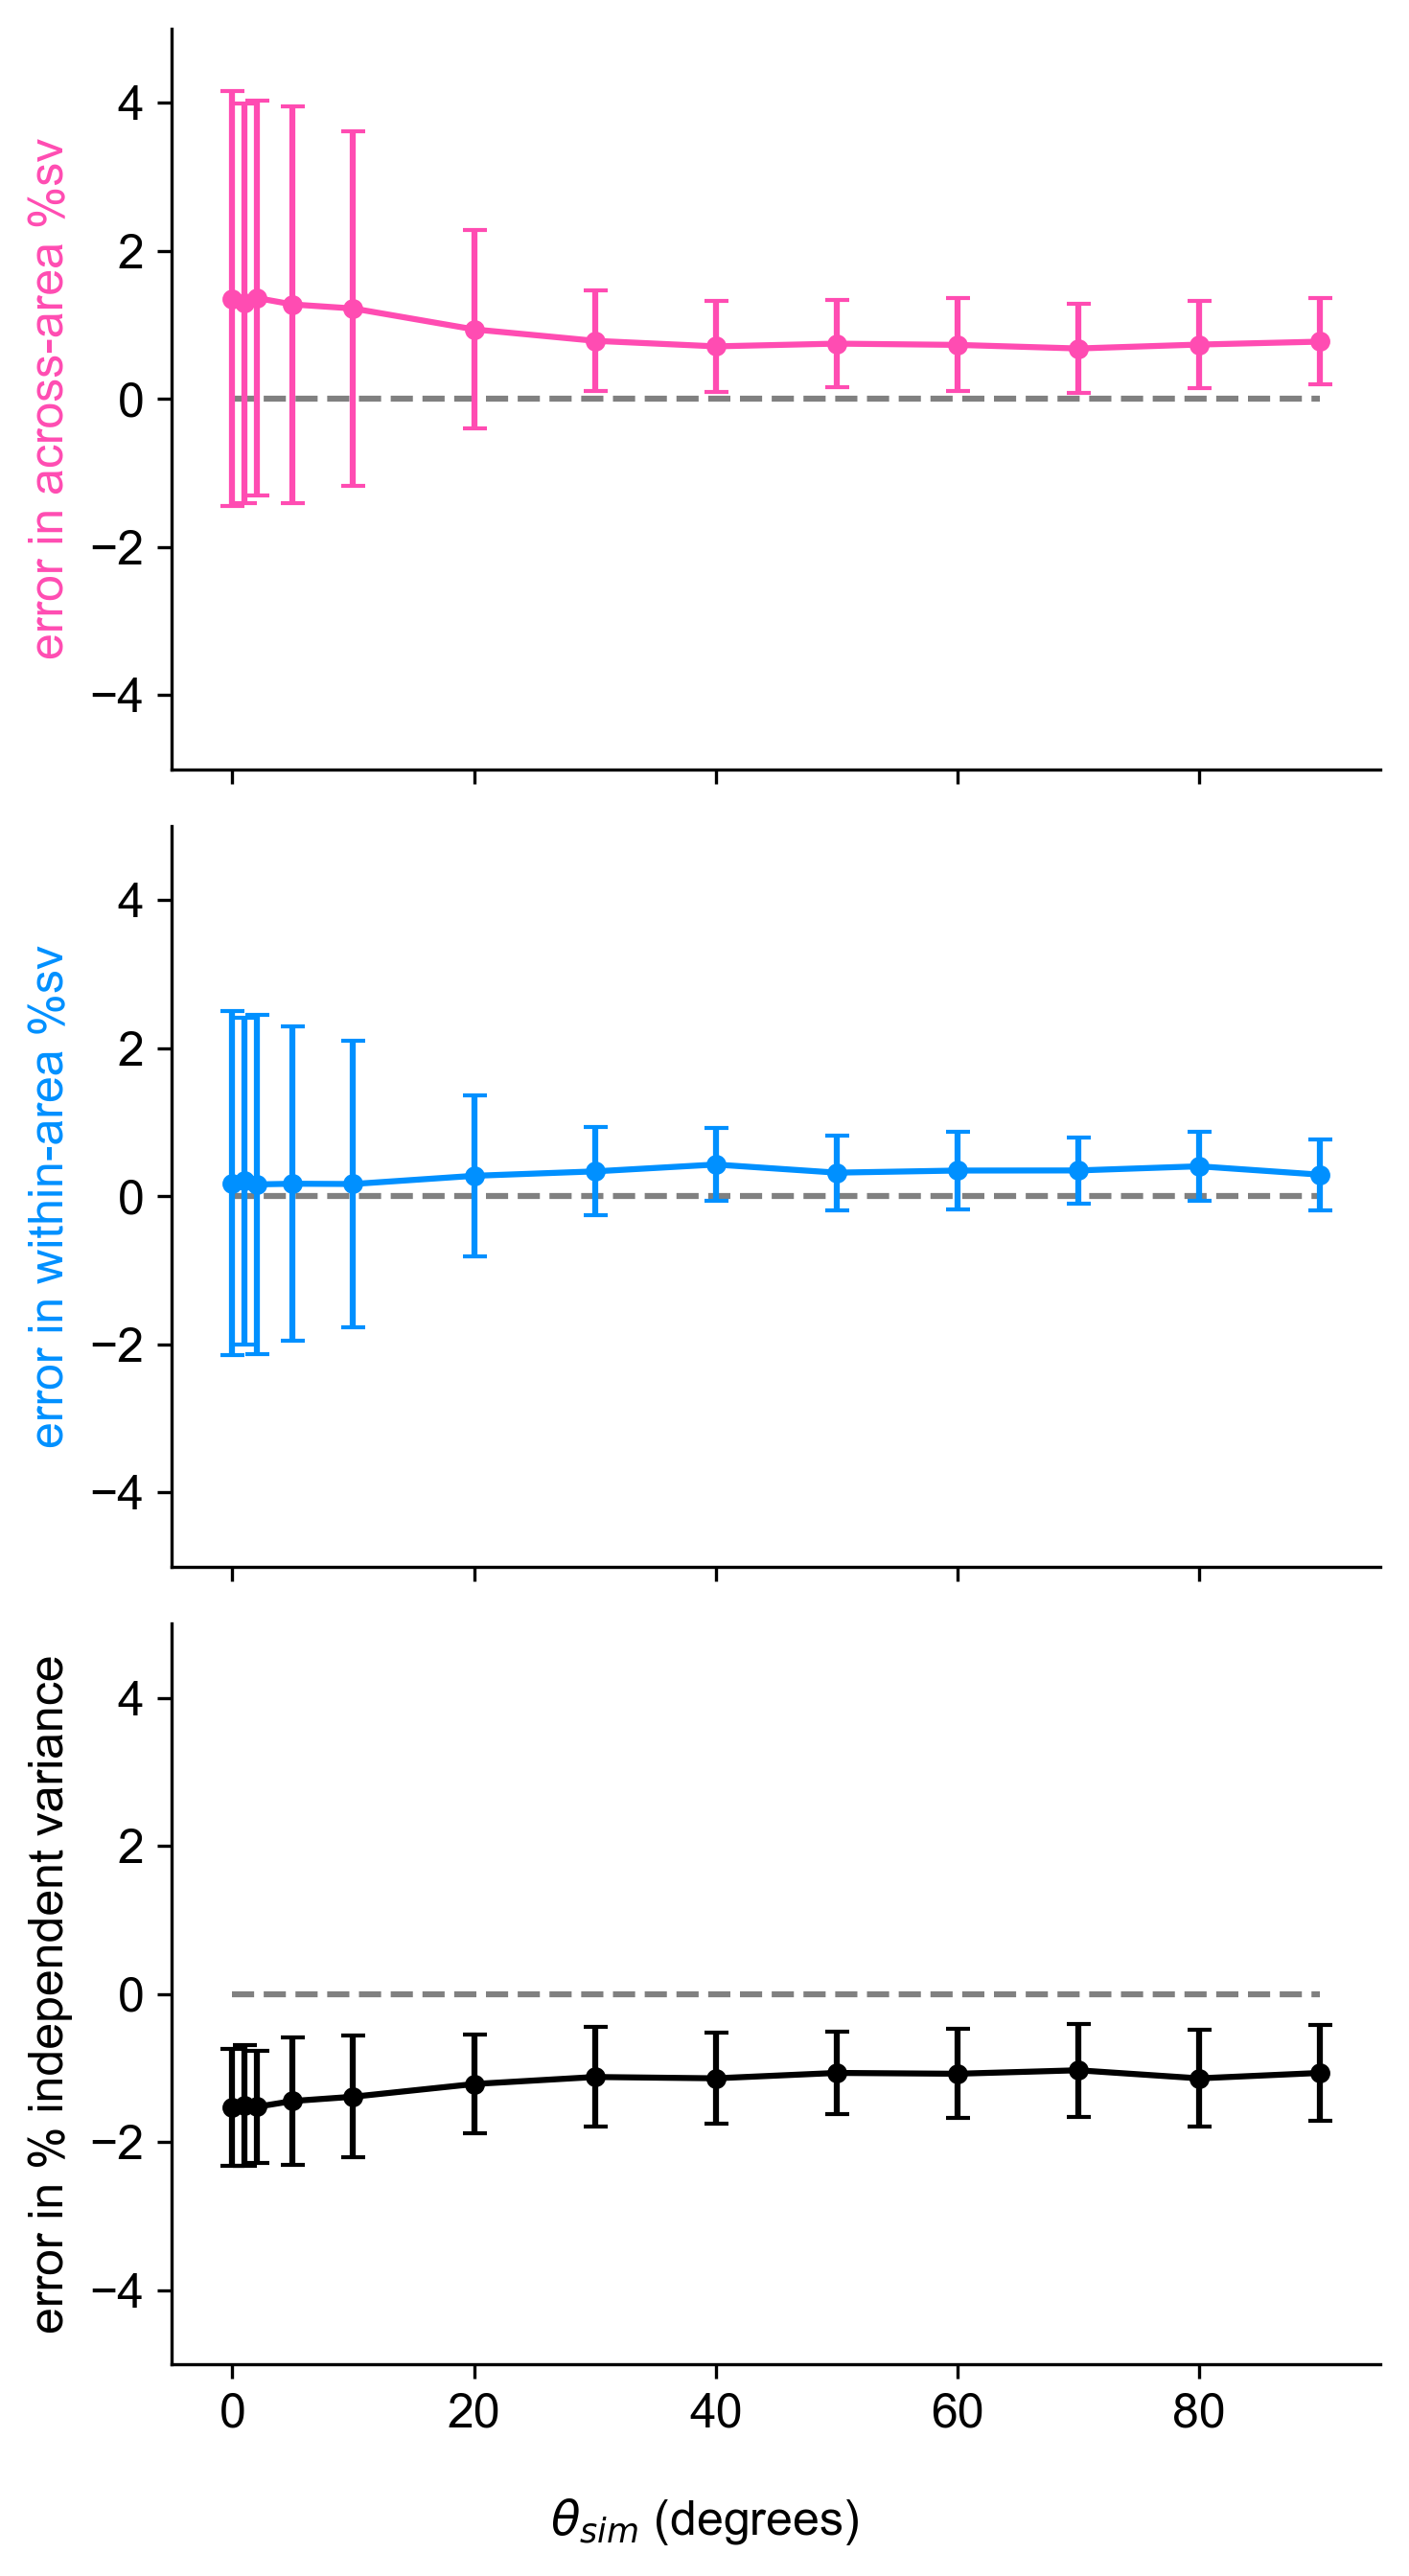

In [16]:
# next panel - mean and std of psv
sv_global_mean, sv_local_mean, ind_mean = [], [], []
sv_global_std, sv_local_std, ind_std = [], [], []
for theta in thetas:
    filt = df['Theta'] == theta

    # calculate error in estimated shared variance
    curr_global = np.concatenate((df[filt]['Error-WxSv'],df[filt]['Error-WySv']))
    curr_local = np.concatenate((df[filt]['Error-LxSv'],df[filt]['Error-LySv']))
    curr_ind = np.concatenate((df[filt]['Error-XIndV'],df[filt]['Error-YIndV']))

    sv_global_mean.append(np.mean(curr_global))
    sv_local_mean.append(np.mean(curr_local))
    ind_mean.append(np.mean(curr_ind))
    sv_global_std.append(np.std(curr_global))
    sv_local_std.append(np.std(curr_local))
    ind_std.append(np.std(curr_ind))

fig,ax = plt.subplots(3,1,sharex=True,tight_layout=True,sharey=True,figsize=(5,9))

fig.supxlabel(r'$\theta_{sim}$ (degrees)')

# ground truth:
ax[0].plot([0,90],[0,0],'--', color='gray') # global
ax[1].plot([0,90],[0,0],'--', color='gray') # local
ax[2].plot([0,90],[0,0],'--', color='gray') # ind

# ests:
ax[0].errorbar(thetas, sv_global_mean, yerr=sv_global_std, fmt='-o', color=color_map['across'], ms=4)
ax[1].errorbar(thetas, sv_local_mean, yerr=sv_local_std, fmt='-o', color=color_map['within'], ms=4)
ax[2].errorbar(thetas, ind_mean, yerr=ind_std, fmt='-o', color='black', ms=4)

ax[0].set_ylabel('error in across-area %sv', color=color_map['across'])
ax[1].set_ylabel('error in within-area %sv', color=color_map['within'])
ax[2].set_ylabel('error in % independent variance', color='black')

ax[0].set_xlim([-5,95])
ax[0].set_ylim([-5,5])
fig.show()

if SAVE_FIG:
    pdf = PdfPages('figs/sv_error_all_theta.pdf')
    pdf.savefig(fig)
    pdf.close()
else:
    fig.show()

In [17]:
# next panel - mean and std of theta
theta_mean = []
theta_std = []
for theta in thetas:
    filt = df['Theta'] == theta

    # calculate error in estimated angle
    curr_theta = np.concatenate((df[filt]['Error-ThetaX'],df[filt]['Error-ThetaY']))
    theta_mean.append(np.mean(curr_theta))
    theta_std.append(np.std(curr_theta))

# fig = plt.subplot()

# # ground truth
# plt.plot([0,90],[0,0],'--', color='gray') # global
# # ests:
# plt.errorbar(thetas, theta_mean, yerr=theta_std, fmt='-o', color='black', ms=4)

# fig.set_ylabel(r'error in $\theta_{estimated}$ (degrees)')
# fig.set_xlabel(r'$\theta_{sim}$ (degrees)')
# fig.set_xlim([-5,95])
# # fig.set_ylim([-5,30])
# plt.show()

# theta_mean = []
# theta_std = []
# for theta in thetas:
#     filt = df['Theta'] == theta

#     # calculate error in estimated angle
#     curr_theta = np.concatenate((df[filt]['Est-ThetaX'],df[filt]['Est-ThetaY']))
#     theta_mean.append(np.mean(curr_theta))
#     theta_std.append(np.std(curr_theta))

# fig = plt.subplot()

# # ground truth
# plt.plot([0,90],[0,90],'--', color='gray') # global
# # ests:
# plt.errorbar(thetas, theta_mean, yerr=theta_std, fmt='-o', color='black', ms=4)

# fig.set_ylabel(r'$\theta_{estimated}$ (degrees)')
# fig.set_xlabel(r'$\theta_{sim}$ (degrees)')
# fig.set_xlim([-5,95])
# # fig.set_ylim([-5,30])
# plt.show()

df.groupby(['Theta']).agg({'Error-ThetaX': ['count', 'mean', np.std],
                           'Error-ThetaY': ['count', 'mean', np.std]})

# if SAVE_FIG:
#     pdf = PdfPages('figs/theta_error_all_theta.pdf')
#     pdf.savefig(fig)
#     pdf.close()
# else:
#     fig.show()

Error-ThetaX                       Error-ThetaY                      
             count       mean        std        count       mean        std
Theta                                                                      
0              100  65.500914  22.226244          100  62.880378  23.874086
1              100  58.940520  24.035170          100  65.858595  20.850108
2              100  61.252509  24.000020          100  59.914842  23.905030
5              100  57.071749  24.239388          100  56.558016  24.337993
10             100  44.417615  24.645536          100  49.251228  22.920951
20             100  18.757947  16.614688          100  16.158099  15.458455
30             100   6.381173   5.235402          100   6.369391   5.362546
40             100   3.309866   4.026486          100   3.432885   3.915158
50             100   2.020482   4.147050          100   1.590097   3.328249
60             100   1.743437   3.564438          100   1.196755   4.539874
70             100   0.494048   3.341102          100   0.616957   3.516324
80             100  -0.248347   3.262224          100   0.142129   3.435535
90             100  -3.033381   2.378932          100  -2.522715   2.250042